In [ ]:
import logging
import matplotlib.pyplot as plt
import numpy as np
import random

from modules import background_model, ModelDataSet, SequenceRepresentation

logging.basicConfig(level=logging.DEBUG, format='%(asctime)s - %(levelname)s - %(message)s')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

np.set_printoptions(precision=4, suppress=True) # Suppress scientific notation for small numbers for better readability

2025-06-12 01:36:07.567513: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-12 01:36:07.637281: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-12 01:36:07.957244: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-12 01:36:08.398221: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749684968.951432   98966 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749684969.09

In [2]:
N = 10
seqlen = 1000
K = 5

In [3]:
def generate_data(model: np.ndarray, N: int, seqlen: int, alphabet: str = "ACGT") -> ModelDataSet.ModelDataSet:
    assert model.shape == (4,), "Model must be a 4 element vector for ACGT alphabet and zeroth order Markov model."
    # Generate random sequences based on the provided model
    data = []
    for _ in range(N):
        seq = random.choices(alphabet, weights=model, k=seqlen)
        # Join the sequence into a string
        seq_str = ''.join(seq)
        # Append the sequence to the data list
        data.append(seq_str)
    # Create a ModelDataSet object with the generated sequences
    genomes = [SequenceRepresentation.Genome([SequenceRepresentation.Sequence(f"n{i}", "chr0", "+", 0, sequence=seq)]) \
               for i, seq in enumerate(data)]
    data = ModelDataSet.ModelDataSet(genomes, ModelDataSet.DataMode.DNA,
                                     tile_size=10, tiles_per_X=1, batch_size=1, prefetch=3) # DO NOT USE TOO LARGE tile_size, as there happens a multiplication along that axis
    assert ''.join(data.alphabet) == "ACGT", f"Alphabet must be ACGT for this model, not {data.alphabet}."
    return data

In [4]:
ground_truth_1 = np.array([0.25, 0.25, 0.25, 0.25])  # Uniform distribution
ground_truth_2 = np.array([0.1, 0.2, 0.3, 0.4])      # Non-uniform distribution
ground_truth_3 = np.array([0.1, 0.4, 0.4, 0.1])      # Another non-uniform distribution

In [5]:
data1 = generate_data(ground_truth_1, N, seqlen)
model1 = background_model.TrainedQ(num_models=K, rand_seed=SEED)
Q1_init = model1.getQ()
m1_init = model1.getM()

2025-06-12 01:36:22.486258: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-06-12 01:36:22,821 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-12 01:36:22,859 - DEBUG - [background_model.__init__] >>> Q_logit shape: (4, 5), m_logit shape: (5,)


In [6]:
data1.getRawData()

[[['...']]]

In [7]:
np.log(1e-10)

np.float64(-23.025850929940457)

In [8]:
losses1 = model1.train(data1, lr=0.01, epochs=100)

2025-06-12 01:36:23,018 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.01
2025-06-12 01:36:25.056502: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-12 01:36:25,070 - INFO - [background_model.train] >>> epoch     0 mean loss = 12.0463, time: 2.05s
2025-06-12 01:36:25.991523: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-12 01:36:27.766882: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-12 01:36:32.015407: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-12 01:36:34,874 - INFO - [background_model.train] >>> epoch    10 mean loss = 10.8490, time: 11.85s
2025-06-12 01:36:39.125414: I tensorflow/core/framework/local_rendezvous.cc:407] Loca

2025-06-12 01:37:50,594 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-06-12 01:37:50,596 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-06-12 01:37:50,608 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2025-06-12 01:37:50,609 - DEBUG - findfont: score(FontEntry(fname='/home/matthis/PhD/genomegraph/.venv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/cmtt10.ttf', name='cmtt10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2025-06-12 01:37:50,610 - DEBUG - findfont: score(FontEntry(fname='/home/matthis/PhD/genomegraph/.venv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 0.05
2025-06-12 01:37:50,610 - DEBUG - findfont: score(FontEntry(fname='/home/matthis/Ph

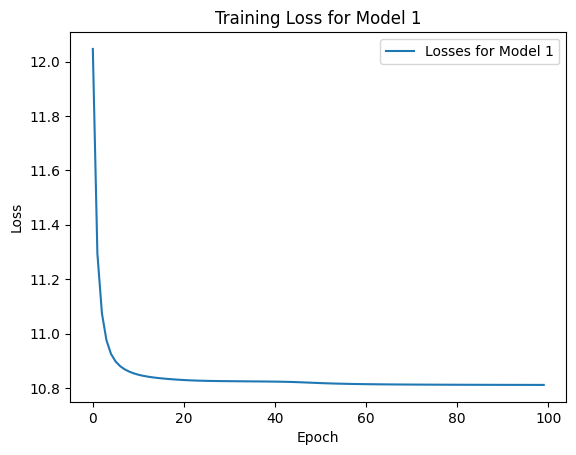

In [9]:
# plot losses1
plt.plot(losses1, label='Losses for Model 1')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss for Model 1')
plt.legend()
plt.show()

In [25]:
print(Q1_init.numpy())
print()
print(m1_init.numpy())

[[0.114 0.047 0.015 0.143 0.012]
 [0.134 0.51  0.927 0.021 0.054]
 [0.007 0.442 0.003 0.279 0.89 ]
 [0.746 0.001 0.056 0.557 0.044]]

[0.104 0.02  0.726 0.003 0.147]


In [26]:
print(model1.getQ().numpy())
print()
print(model1.getM().numpy())

[[0.267 0.005 0.236 0.271 0.044]
 [0.233 0.382 0.002 0.229 0.294]
 [0.233 0.613 0.003 0.229 0.355]
 [0.267 0.    0.758 0.271 0.307]]

[0.651 0.028 0.015 0.001 0.305]


In [20]:
print(ground_truth_1)

[0.25 0.25 0.25 0.25]


---

2025-06-12 01:37:51,050 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-12 01:37:51,073 - DEBUG - [background_model.__init__] >>> Q_logit shape: (4, 5), m_logit shape: (5,)
2025-06-12 01:37:51,087 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.01
2025-06-12 01:37:52,344 - INFO - [background_model.train] >>> epoch     0 mean loss = 11.1947, time: 1.25s
2025-06-12 01:38:00,944 - INFO - [background_model.train] >>> epoch    10 mean loss = 9.1683, time: 9.85s
2025-06-12 01:38:09,002 - INFO - [background_model.train] >>> epoch    20 mean loss = 9.1591, time: 17.91s
2025-06-12 01:38:15.595018: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-06-12 01:38:18,051 - INFO - [background_model.train] >>> epoch    30 mean loss = 9.1558, time: 26.96s
2025-06-12 01:38:26,273 - INFO - [background_model.train] >>> epoch    40 mean loss = 9.1538, time: 35.18s
2025-06-12 01:38:34,467 - INFO -

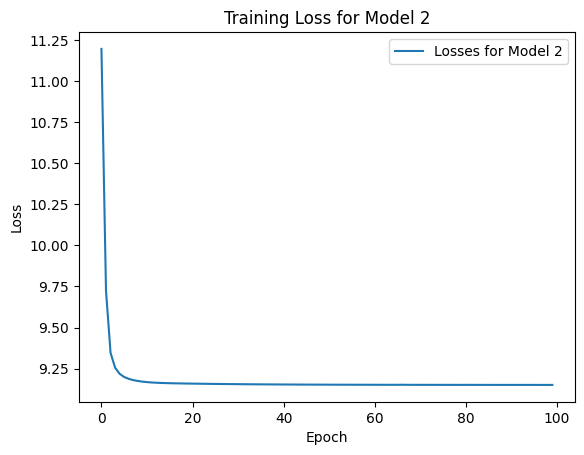

In [12]:
data2 = generate_data(ground_truth_2, N, seqlen)
model2 = background_model.TrainedQ(num_models=K, rand_seed=SEED)
Q2_init = model2.getQ()
m2_init = model2.getM()

losses2 = model2.train(data2, lr=0.01, epochs=100)

# plot losses2
plt.plot(losses2, label='Losses for Model 2')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss for Model 2')
plt.legend()
plt.show()

In [27]:
print(Q2_init.numpy())
print()
print(m2_init.numpy())

[[0.114 0.047 0.015 0.143 0.012]
 [0.134 0.51  0.927 0.021 0.054]
 [0.007 0.442 0.003 0.279 0.89 ]
 [0.746 0.001 0.056 0.557 0.044]]

[0.104 0.02  0.726 0.003 0.147]


In [28]:
print(model2.getQ().numpy())
print()
print(model2.getM().numpy())

[[0.007 0.001 0.381 0.045 0.009]
 [0.227 0.484 0.572 0.003 0.138]
 [0.021 0.516 0.    0.573 0.338]
 [0.745 0.    0.047 0.379 0.516]]

[0.033 0.012 0.036 0.004 0.915]


In [29]:
print(ground_truth_2)

[0.1 0.2 0.3 0.4]


---

2025-06-12 01:39:16,818 - DEBUG - [model.__init__] >>> setting tf global seed to 42
2025-06-12 01:39:16,839 - DEBUG - [background_model.__init__] >>> Q_logit shape: (4, 5), m_logit shape: (5,)
2025-06-12 01:39:16,850 - DEBUG - [model.train.setLR] >>> Setting learning rate to 0.01
2025-06-12 01:39:18,091 - INFO - [background_model.train] >>> epoch     0 mean loss = 8.1807, time: 1.24s
2025-06-12 01:39:26,432 - INFO - [background_model.train] >>> epoch    10 mean loss = 7.2738, time: 9.58s
2025-06-12 01:39:34,498 - INFO - [background_model.train] >>> epoch    20 mean loss = 7.2694, time: 17.65s
2025-06-12 01:39:42,764 - INFO - [background_model.train] >>> epoch    30 mean loss = 7.2680, time: 25.91s
2025-06-12 01:39:51,718 - INFO - [background_model.train] >>> epoch    40 mean loss = 7.2672, time: 34.87s
2025-06-12 01:39:59,802 - INFO - [background_model.train] >>> epoch    50 mean loss = 7.2666, time: 42.95s
2025-06-12 01:40:03.970306: I tensorflow/core/framework/local_rendezvous.cc:407

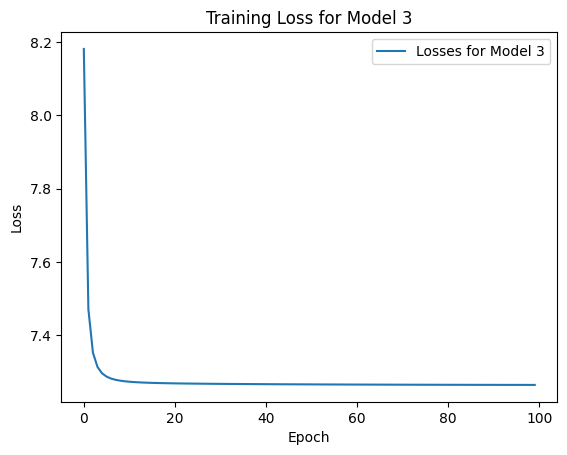

In [16]:
data3 = generate_data(ground_truth_3, N, seqlen)
model3 = background_model.TrainedQ(num_models=K, rand_seed=SEED)
Q3_init = model3.getQ()
m3_init = model3.getM()

losses3 = model3.train(data3, lr=0.01, epochs=100)

# plot losses3
plt.plot(losses3, label='Losses for Model 3')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss for Model 3')
plt.legend()
plt.show()

In [30]:
print(Q3_init.numpy())
print()
print(m3_init.numpy())

[[0.114 0.047 0.015 0.143 0.012]
 [0.134 0.51  0.927 0.021 0.054]
 [0.007 0.442 0.003 0.279 0.89 ]
 [0.746 0.001 0.056 0.557 0.044]]

[0.104 0.02  0.726 0.003 0.147]


In [31]:
print(model3.getQ().numpy())
print()
print(model3.getM().numpy())

[[0.    0.056 0.    0.107 0.001]
 [0.759 0.49  0.759 0.036 0.454]
 [0.001 0.454 0.001 0.501 0.489]
 [0.24  0.    0.241 0.356 0.055]]

[0.001 0.015 0.009 0.    0.975]


In [19]:
print(ground_truth_3)

[0.1 0.4 0.4 0.1]
